# Домашнее задание по линейной регрессии
Я использовал датасет для регрессии цены медицинской страховки (Medical Cost Personal Datasets https://www.kaggle.com/datasets/mirichoi0218/insurance)

# Прежде чем запускать обратите внимание на переменную SEARCH_NJOBS в первом блоке кода!
Поменяйте этот параметр в зависимости от вычислительных мощностей вашей машины, от него зависит скорость выполнения метода `fit` в `GridSearchCV` (сколько параллельных потоков запускать). Если взять слишком большой параметр, то питон съест все ресурсы машины и система будет тормозить (по крайней мере у меня так было). При параметре =50 `fit` выполнялись примерно 2 минуты 10 секунд.

### 1. EDA & preprocessing

In [47]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
SEARCH_NJOBS = 50

df = pd.read_csv("insurance.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [48]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Видно, что пропущенных полей нет, так что сразу посмотрим на корелляцию, для этого сначала построим двумерные графики зависимостей цены дома от разных признаков, а затем построим матрицу корреляций.

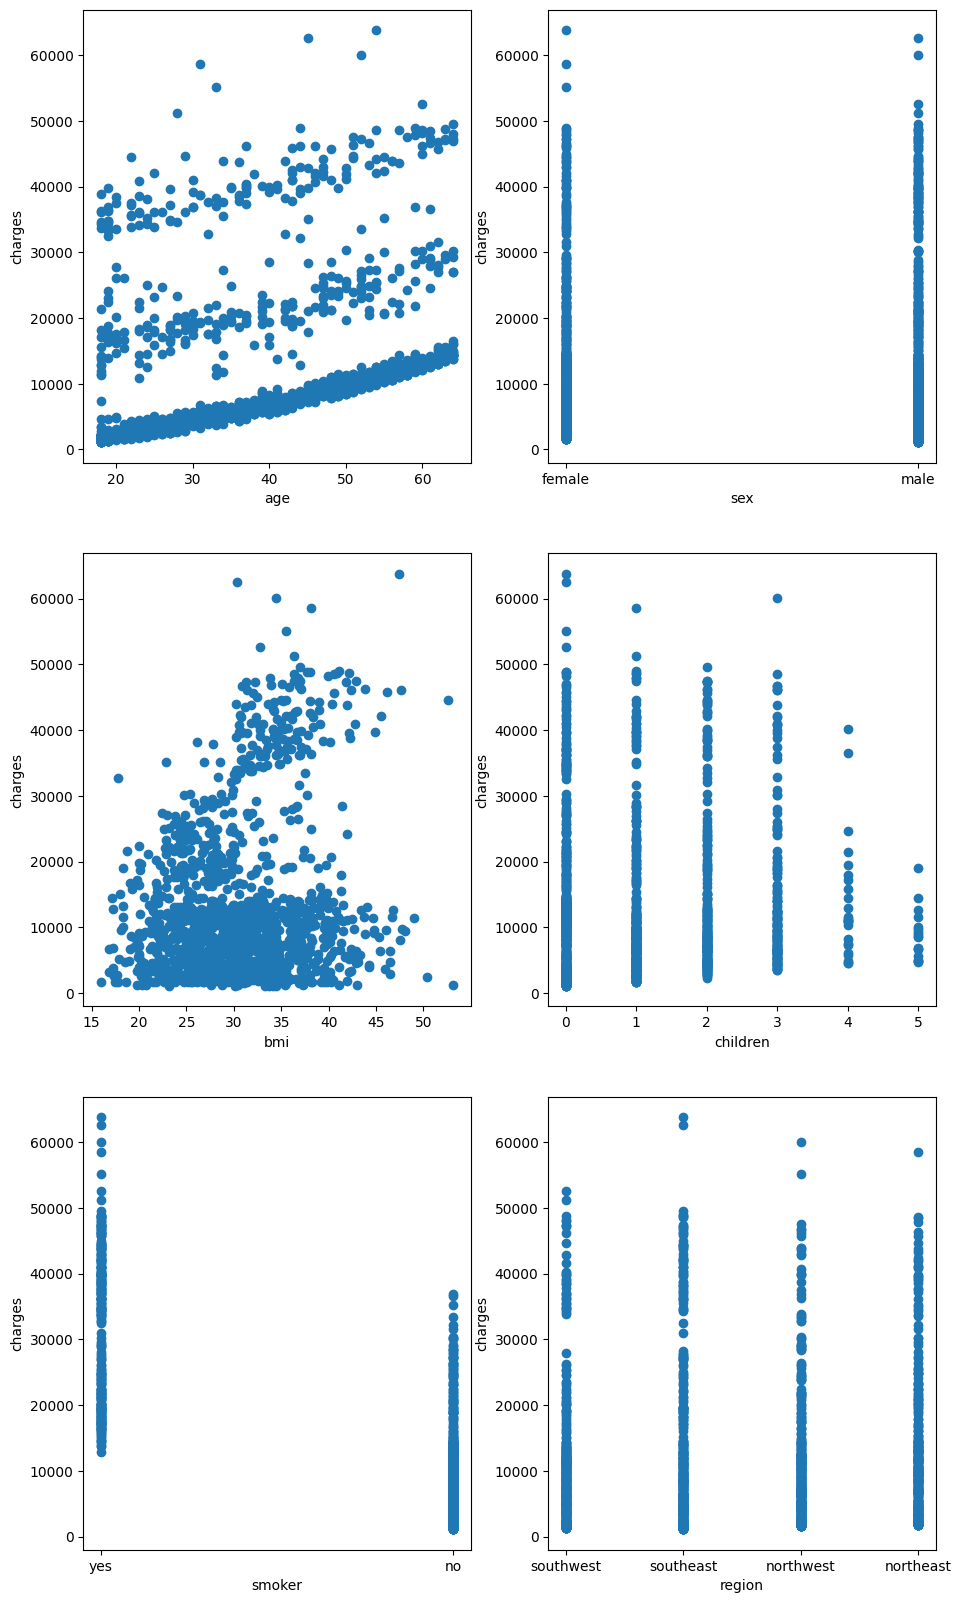

In [49]:
for ax, x in zip(plt.figure(figsize=(11,20)).subplots(3, 2).ravel(), df.columns):
    ax.scatter(df[x], df['charges'])
    ax.set_xlabel(x)
    ax.set_ylabel('charges')

plt.show()

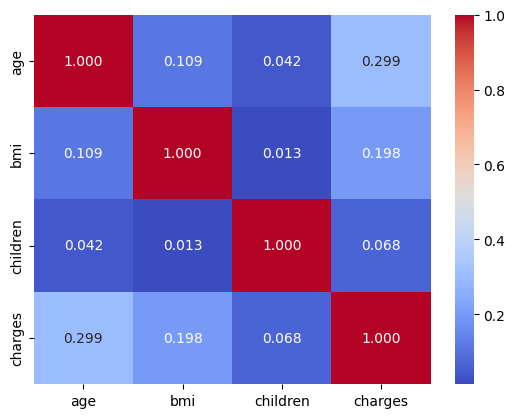

In [50]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt=".3f", cmap='coolwarm')
plt.show()

Теперь закодируем строковые признаки с помощью OneHotEncoder и посмотрим на поллную матрицу корреляции. Тут нужно использовать drop='first', т.к. первая колонка будет полностью отрицательно коррелировать со второй (если значений признака всего 2) для каждого закодированного признака.

In [51]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
df_encoded_part = pd.DataFrame(encoder.fit_transform(df.select_dtypes('str')))
df_encoded_part.columns = encoder.get_feature_names_out()
df_encoded_part.head()

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0


In [52]:
df_encoded = df.drop(df.select_dtypes('str').columns, axis='columns').join(df_encoded_part)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0


Вообще говоря, кодирование признаков нужно делать после `train_test_split`, чтобы модель не обучалась на тестовых данных, но в случае `OneHotEncoder` особо ничего не изменится, если мы сделаем кодеирование перед делением (если бы мы так сделали например со скейлером, то модель бы переобучалась). Сделав кодирование до деления, мы сможем нарисовать красивые диаграммы и получить больше информации при EDA.

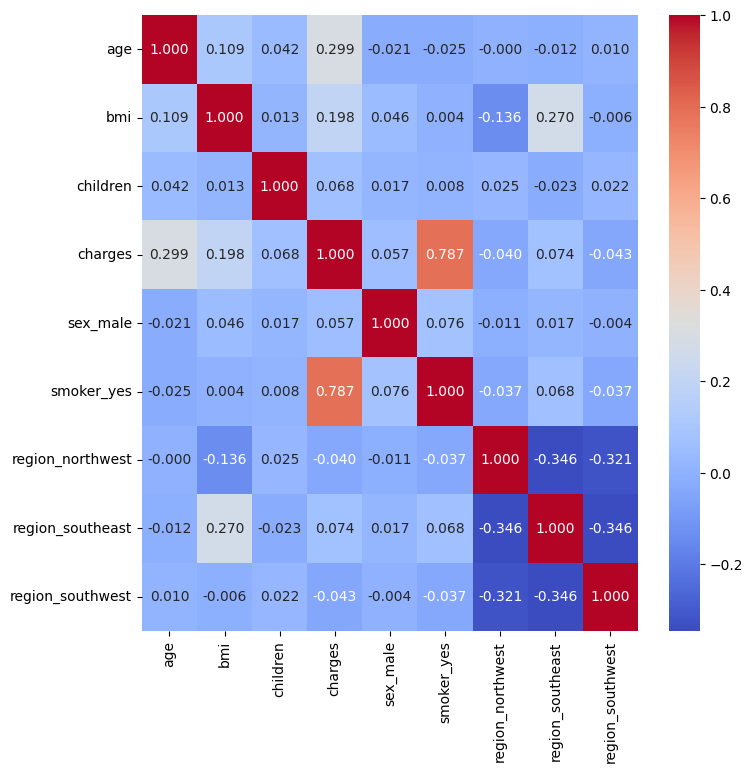

In [53]:
plt.figure(figsize=(8,8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".3f", cmap='coolwarm')
plt.show()

Видно, что от того, курит ли человек, сильно зависят его расходы на медицинскую помощь.

### 2. Подготовка данных

Теперь разделим данные на train и test используя `train_test_split()`. Это нужно, чтобы модель видела тестовые данные впервые (то есть чтобы она могла реально предсказыввать реальные данные, а не просто идеально "заучить" тренировочные данные и плохо предсказывать новые). Если бы мы не разделили данные, то при тестировании score модели получался не объективным (то есть буквально никак не показывал как модель решает поставленную задачу, а именно предсказание новых данных после обучения на тренировочных) потому что модель уже виделы эти данные при обучении. В данном случае исходные данные делятся на train и test в соотношении 80% на 20% соответственно.

In [54]:
X = df_encoded.drop(columns='charges')
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape)
print(X_test.shape)

X_train = pd.DataFrame(X_train)
X_train.columns = X.columns

X_test = pd.DataFrame(X_test)
X_test.columns = X.columns

(1070, 8)
(268, 8)


Тут следует добавить, что я не стану делать почти никакого feature engineering'a потому что далее я буду использовать для этого класс `PolynomialFeatures` который просто создает комбинации (перемножает и возводит в степень) фичей автоматически. Однако еще чуть позже я попытаюсь удалить признаки с низкой корреляцией с целевой переменной.

### 3. Тренировка моделей

В качестве модели я возьму класс `LinearRegression` из sklearn.

In [55]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

def print_prediction_scores(model, y_pred, y_test, cv):
    print("MSE: ", mean_squared_error(y_test, y_pred))
    print("MSPE: ", np.sum(((y_test - y_pred) / y_test) ** 2) / y_test.shape[0] * 100, " %")
    print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE: ", mean_absolute_error(y_test, y_pred))
    print("MAPE: ", mean_absolute_percentage_error(y_test, y_pred) * 100, " %")
    print("R2: ", r2_score(y_test, y_pred))
    print("CV({}) r2 mean: ".format(cv), np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')))

print_prediction_scores(linreg, y_pred, y_test, 5)


MSE:  33596915.85136146
MSPE:  47.34684000412982  %
RMSE:  5796.2846592762735
MAE:  4181.194473753654
MAPE:  46.88825597914696  %
R2:  0.7835929767120723
CV(5) r2 mean:  0.7331101109097585


Теперь попробуем использовать перед линейной регрессией класс `PolynomialFeatures` для рассмотрения комбинаций признаков. Для этого создадим объект класса `PipeLine` чтобы объединить шаги в один estimator.

In [56]:
steps = [
    ('polyfeatures', PolynomialFeatures(degree=2)),
    ('linreg', LinearRegression())
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)
print_prediction_scores(pipeline, pipeline.predict(X_test), y_test, 5)

MSE:  20712805.987918355
MSPE:  16.60320586144518  %
RMSE:  4551.132385233191
MAE:  2729.5001336394453
MAPE:  30.19857802271423  %
R2:  0.8665830903164841
CV(5) r2 mean:  0.8268445143163378


Теперь обучим модели с L1 и L2.

In [57]:
steps_L2 = [
    ('polyfeatures', PolynomialFeatures(degree=2)),
    ('linreg', Ridge(max_iter=20000, random_state=RANDOM_STATE))
]
L2 = Pipeline(steps_L2)
L2.fit(X_train, y_train)
print('L2 scores:')
print_prediction_scores(L2, L2.predict(X_test), y_test, 5)
print("Weights max: ", np.max(L2.named_steps['linreg'].coef_))

steps_L1 = [
    ('polyfeatures', PolynomialFeatures(degree=2)),
    ('linreg', Lasso(max_iter=20000, random_state=RANDOM_STATE))
]
L1 = Pipeline(steps_L1)
L1.fit(X_train, y_train)
print('\nL1 scores:')
print_prediction_scores(L1, L1.predict(X_test), y_test, 5)
print("Weights max: ", np.max(L1.named_steps['linreg'].coef_))

steps_ElasticNet = [
    ('polyfeatures', PolynomialFeatures(degree=2)),
    ('linreg', ElasticNet(max_iter=20000, random_state=RANDOM_STATE))
]
EN = Pipeline(steps_ElasticNet)
EN.fit(X_train, y_train)
print('\nElasticNet scores:')
print_prediction_scores(EN, EN.predict(X_test), y_test, 5)
print("Weights max: ", np.max(EN.named_steps['linreg'].coef_))




L2 scores:
MSE:  20656391.238945596
MSPE:  16.00580441265206  %
RMSE:  4544.930278777178
MAE:  2729.408699911584
MAPE:  29.786190668769347  %
R2:  0.8669464733111835
CV(5) r2 mean:  0.826737291513614
Weights max:  1429.0651766067404

L1 scores:
MSE:  20673886.416932892
MSPE:  16.471516230016256  %
RMSE:  4546.854562984491
MAE:  2728.6351424954805
MAPE:  30.160617788072546  %
R2:  0.8668337820330057
CV(5) r2 mean:  0.8269994534280464
Weights max:  1468.154573691695

ElasticNet scores:
MSE:  21668352.245430384
MSPE:  12.09414972407002  %
RMSE:  4654.927737938623
MAE:  2906.3086961671343
MAPE:  27.857248072038672  %
R2:  0.8604281526990861
CV(5) r2 mean:  0.8138535129401985
Weights max:  933.960008758217


Видно, что алгоритмы примерно равны по результатам (все они плохие, т.к. в случае предсказания размер выплат, нам лучше всего минимизировать метрики MSPE или MAPE, так что будем в дальнейшем применять скейлеры чтобы уменьшить эти метрики), но для поиска гиперпараметров будем использовать ElsticNet т.к это смесь L1 и L2. То есть при правильных параметрах из `ElasticNet` можно получить  `Ridge` и `Lasso` (ниже представлено описание формулы функции потерь внутри класса ElasticNet):

Linear regression with combined L1 and L2 priors as regularizer.

Minimizes the objective function:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mfrac>
    <mn>1</mn>
    <mrow>
      <mn>2</mn>
      <msub>
        <mi>n</mi>
        <mrow data-mjx-texclass="ORD">
          <mi mathvariant="normal">s</mi>
          <mi mathvariant="normal">a</mi>
          <mi mathvariant="normal">m</mi>
          <mi mathvariant="normal">p</mi>
          <mi mathvariant="normal">l</mi>
          <mi mathvariant="normal">e</mi>
          <mi mathvariant="normal">s</mi>
        </mrow>
      </msub>
    </mrow>
  </mfrac>
  <mo>&#x22C5;</mo>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mi>y</mi>
  <mo>&#x2212;</mo>
  <mi>X</mi>
  <mi>w</mi>
  <msubsup>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>2</mn>
    <mn>2</mn>
  </msubsup>
  <mo>+</mo>
  <mi>&#x3B1;</mi>
  <mo>&#x22C5;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="normal">l</mi>
    <mn>1</mn>
    <mi mathvariant="normal">_</mi>
    <mrow data-mjx-texclass="ORD">
      <mi mathvariant="normal">r</mi>
      <mi mathvariant="normal">a</mi>
      <mi mathvariant="normal">t</mi>
      <mi mathvariant="normal">i</mi>
      <mi mathvariant="normal">o</mi>
    </mrow>
  </mrow>
  <mo>&#x22C5;</mo>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mi>w</mi>
  <msub>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>1</mn>
  </msub>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo>&#x22C5;</mo>
  <mi>&#x3B1;</mi>
  <mo>&#x22C5;</mo>
  <mo stretchy="false">(</mo>
  <mn>1</mn>
  <mo>&#x2212;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="normal">l</mi>
    <mn>1</mn>
    <mi mathvariant="normal">_</mi>
    <mrow data-mjx-texclass="ORD">
      <mi mathvariant="normal">r</mi>
      <mi mathvariant="normal">a</mi>
      <mi mathvariant="normal">t</mi>
      <mi mathvariant="normal">i</mi>
      <mi mathvariant="normal">o</mi>
    </mrow>
  </mrow>
  <mo stretchy="false">)</mo>
  <mo>&#x22C5;</mo>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mi>w</mi>
  <msubsup>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>2</mn>
    <mn>2</mn>
  </msubsup>
</math>

If you are interested in controlling the L1 and L2 penalty separately, keep in mind that this is equivalent to:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>a</mi>
  <mo>&#x22C5;</mo>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mi>w</mi>
  <msub>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>1</mn>
  </msub>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo>&#x22C5;</mo>
  <mi>b</mi>
  <mo>&#x22C5;</mo>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mi>w</mi>
  <msubsup>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>2</mn>
    <mn>2</mn>
  </msubsup>
</math>

where:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>&#x3B1;</mi>
  <mo>=</mo>
  <mi>a</mi>
  <mo>+</mo>
  <mi>b</mi>
  <mo>,</mo>
  <mstyle scriptlevel="0">
    <mspace width="1em"></mspace>
  </mstyle>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="normal">l</mi>
    <mn>1</mn>
    <mi mathvariant="normal">_</mi>
    <mrow data-mjx-texclass="ORD">
      <mi mathvariant="normal">r</mi>
      <mi mathvariant="normal">a</mi>
      <mi mathvariant="normal">t</mi>
      <mi mathvariant="normal">i</mi>
      <mi mathvariant="normal">o</mi>
    </mrow>
  </mrow>
  <mo>=</mo>
  <mfrac>
    <mi>a</mi>
    <mrow>
      <mi>a</mi>
      <mo>+</mo>
      <mi>b</mi>
    </mrow>
  </mfrac>
</math>

The parameter l1_ratio corresponds to alpha in the glmnet R package while alpha corresponds to the lambda parameter in glmnet. Specifically, l1_ratio = 1 is the lasso penalty. Currently, l1_ratio <= 0.01 is not reliable, unless you supply your own sequence of alpha.

Теперь используем GridSearchCV чтобы подобрать параметры для ElasticNet.

Для начала добавим StandardScaler в шаги пайплайна чтобы получить результат получше.

In [58]:
steps_ElasticNet.insert(0, ('scaler', StandardScaler()))
EN = Pipeline(steps_ElasticNet)
EN.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('polyfeatures', PolynomialFeatures()),
  ('linreg', ElasticNet(max_iter=20000, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'polyfeatures': PolynomialFeatures(),
 'linreg': ElasticNet(max_iter=20000, random_state=42),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'polyfeatures__degree': 2,
 'polyfeatures__include_bias': True,
 'polyfeatures__interaction_only': False,
 'polyfeatures__order': 'C',
 'linreg__alpha': 1.0,
 'linreg__copy_X': True,
 'linreg__fit_intercept': True,
 'linreg__l1_ratio': 0.5,
 'linreg__max_iter': 20000,
 'linreg__positive': False,
 'linreg__precompute': False,
 'linreg__random_state': 42,
 'linreg__selection': 'cyclic',
 'linreg__tol': 0.0001,
 'linreg__warm_start': False}

In [59]:
param_grid = {
    'scaler__with_mean' : [True, False],
    'scaler__with_std' : [True, False],
    'polyfeatures__degree' : [1,2,3,4],
    'polyfeatures__interaction_only' : [True, False],
    'linreg__alpha' : [0.01, 0.1, 10, 100],
    'linreg__l1_ratio' : [i * 0.1 for i in range(0, 11)],
    'linreg__max_iter' : [2000]
}

search_first = GridSearchCV(param_grid=param_grid, estimator=EN, scoring='neg_mean_absolute_percentage_error', n_jobs=SEARCH_NJOBS)
search_first.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'linreg__alpha': [0.01, 0.1, ...], 'linreg__l1_ratio': [0.0, 0.1, ...], 'linreg__max_iter': [2000], 'polyfeatures__degree': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",50
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

Посмотрим теперь на результаты (сначала отсортируем по score):

In [60]:
search_res = pd.DataFrame(search_first.cv_results_)
search_res.sort_values(by='rank_test_score', ascending=True).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_linreg__alpha,param_linreg__l1_ratio,param_linreg__max_iter,param_polyfeatures__degree,param_polyfeatures__interaction_only,param_scaler__with_mean,param_scaler__with_std,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1387,0.014444,0.003258,0.006436,0.003233,100.00,1.0,2000,2,True,False,False,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",-0.265525,-0.265223,-0.282634,-0.277195,-0.246067,-0.267329,0.012580,1
43,0.039899,0.026691,0.016779,0.024625,0.01,0.1,2000,2,True,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.265946,-0.263977,-0.289835,-0.288768,-0.251689,-0.272043,0.014919,2
75,0.060313,0.027102,0.004486,0.000580,0.01,0.2,2000,2,True,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.265479,-0.264402,-0.289566,-0.288798,-0.252247,-0.272099,0.014705,3
651,0.138902,0.056897,0.038063,0.063446,0.10,0.9,2000,2,True,False,False,"{'linreg__alpha': 0.1, 'linreg__l1_ratio': 0.9...",-0.266482,-0.263728,-0.290420,-0.288701,-0.251237,-0.272114,0.015153,4
11,0.091046,0.023462,0.006228,0.001285,0.01,0.0,2000,2,True,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.266464,-0.263701,-0.290429,-0.288731,-0.251262,-0.272117,0.015160,5


Из интересного тут то, что в топ 5 попали только чистые `Lasso` с разными параметрами `StandardScaler` и `PolynomialFeatures`.

In [61]:
search_res.sort_values(by='mean_fit_time', ascending=True).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_linreg__alpha,param_linreg__l1_ratio,param_linreg__max_iter,param_polyfeatures__degree,param_polyfeatures__interaction_only,param_scaler__with_mean,param_scaler__with_std,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
131,0.008556,0.000424,0.003681,0.000238,0.01,0.4,2000,1,True,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.446389,-0.403905,-0.470848,-0.434216,-0.415630,-0.434198,0.023470,769
101,0.008737,0.000192,0.003699,0.000215,0.01,0.3,2000,1,False,True,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.448441,-0.405424,-0.472429,-0.436358,-0.418106,-0.436152,0.023396,788
130,0.008871,0.000254,0.003905,0.000584,0.01,0.4,2000,1,True,False,True,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.435997,-0.395958,-0.461906,-0.424098,-0.403912,-0.424374,0.023537,705
134,0.008877,0.000345,0.003569,0.000046,0.01,0.4,2000,1,False,False,True,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",-0.435997,-0.395958,-0.461906,-0.424098,-0.403912,-0.424374,0.023537,705
519,0.008905,0.000169,0.004572,0.000557,0.10,0.5,2000,1,False,False,False,"{'linreg__alpha': 0.1, 'linreg__l1_ratio': 0.5...",-0.533975,-0.479524,-0.546039,-0.532154,-0.527364,-0.523811,0.022983,938


Тут видно, что быстрее всего обучались модели, где значение степени в `PolyFeatures` равно 1, это логично, потому что так нужно рассчитывать шаг градиентного спуска для меньшего числа измерений (то есть меньшего числа координат вектора весов, потому что самих координат банально меньше). Чтобы убедиться в этом предположении, построим график зависимости времени обучения от степени в `PolyFeatures`:

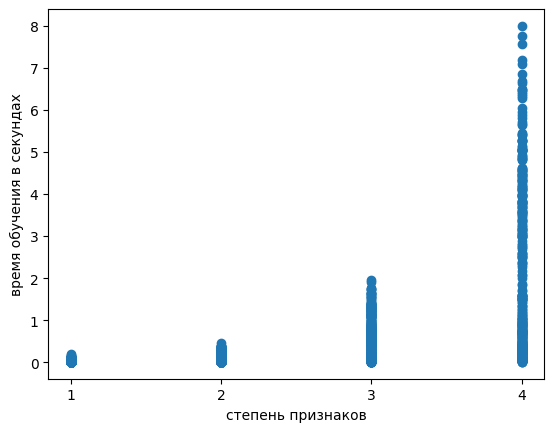

In [62]:
ax = plt.axes()
ax.scatter(search_res['param_polyfeatures__degree'], search_res['mean_fit_time'])
ax.set_ylabel('время обучения в секундах')
ax.set_xlabel('степень признаков')
ax.set_xticks([1, 2, 3, 4])
plt.show()

На графике видно что-то вроде экспоненциальной зависимости, однако разброс очень большой. Теперь получим лучшие параметры и лучший score:

In [63]:
best_EN_MAPE = search_first.best_estimator_
best_EN_MAPE.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler(with_mean=False, with_std=False)),
  ('polyfeatures', PolynomialFeatures(interaction_only=True)),
  ('linreg',
   ElasticNet(alpha=100, l1_ratio=1.0, max_iter=2000, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(with_mean=False, with_std=False),
 'polyfeatures': PolynomialFeatures(interaction_only=True),
 'linreg': ElasticNet(alpha=100, l1_ratio=1.0, max_iter=2000, random_state=42),
 'scaler__copy': True,
 'scaler__with_mean': False,
 'scaler__with_std': False,
 'polyfeatures__degree': 2,
 'polyfeatures__include_bias': True,
 'polyfeatures__interaction_only': True,
 'polyfeatures__order': 'C',
 'linreg__alpha': 100,
 'linreg__copy_X': True,
 'linreg__fit_intercept': True,
 'linreg__l1_ratio': 1.0,
 'linreg__max_iter': 2000,
 'linreg__positive': False,
 'linreg__precompute': False,
 'linreg__random_state': 42,
 'linreg__selection': 'cyclic',
 'linreg__tol': 0.0001,
 'linreg__warm_start': Fa

In [64]:
search_first.best_score_

np.float64(-0.2673287941116823)

По параметрам видно, что получилось L1 с параметром альфа равным 100. Но сам результат все еще не очень, т.к. метрика MAPE все еще дает больше 10% то есть средний разброс по стоимости все еще большой (что самое странное, так это то, что скейлер лучше всего получилось использовать с параметрами `'scaler__with_mean': False, 'scaler__with_std': False`, то есть по сути он ничего не делает), хотя если искать для метрики R2 (насколько модель лучше полностью случайных предсказаний), то получим следующее:

In [79]:
search_second = GridSearchCV(param_grid=param_grid, estimator=EN, scoring='r2', n_jobs=SEARCH_NJOBS)
search_second.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'linreg__alpha': [0.01, 0.1, ...], 'linreg__l1_ratio': [0.0, 0.1, ...], 'linreg__max_iter': [2000], 'polyfeatures__degree': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",50
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [80]:
search_res = pd.DataFrame(search_second.cv_results_)
search_res.sort_values(by='rank_test_score', ascending=True).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_linreg__alpha,param_linreg__l1_ratio,param_linreg__max_iter,param_polyfeatures__degree,param_polyfeatures__interaction_only,param_scaler__with_mean,param_scaler__with_std,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1396,0.320316,0.124739,0.012689,0.012997,100.0,1.0,2000,3,False,True,True,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",0.826869,0.894449,0.805097,0.755830,0.862172,0.828884,0.047568,1
1388,0.116888,0.080309,0.075848,0.069718,100.0,1.0,2000,2,False,True,True,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",0.824330,0.894343,0.807688,0.760761,0.856474,0.828719,0.045071,2
1404,2.608251,0.736999,0.007473,0.001932,100.0,1.0,2000,4,False,True,True,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",0.828870,0.883137,0.804035,0.765963,0.861429,0.828687,0.041422,3
1390,0.088481,0.081858,0.040733,0.069981,100.0,1.0,2000,2,False,False,True,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",0.822784,0.892789,0.809667,0.759483,0.858378,0.828620,0.045114,4
1389,0.041678,0.054066,0.012662,0.012730,100.0,1.0,2000,2,False,True,False,"{'linreg__alpha': 100, 'linreg__l1_ratio': 1.0...",0.822347,0.895967,0.804689,0.761395,0.855535,0.827986,0.045584,5


In [92]:
search_res.sort_values(by='mean_fit_time', ascending=True).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_linreg__alpha,param_linreg__l1_ratio,param_linreg__max_iter,param_polyfeatures__degree,param_polyfeatures__interaction_only,param_scaler__with_mean,param_scaler__with_std,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
38,0.005464,0.000333,0.002282,0.000052,0.01,0.1,2000,1,False,False,True,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",0.715910,0.801578,0.723412,0.658912,0.766090,0.733180,0.048313,790
34,0.006462,0.000709,0.043272,0.081302,0.01,0.1,2000,1,True,False,True,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",0.715910,0.801578,0.723412,0.658912,0.766090,0.733180,0.048313,790
35,0.006669,0.001376,0.042224,0.077762,0.01,0.1,2000,1,True,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",0.713164,0.799422,0.722832,0.662234,0.761419,0.731814,0.046297,895
167,0.007010,0.000314,0.003034,0.000019,0.01,0.5,2000,1,False,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",0.714719,0.801099,0.723322,0.660848,0.764092,0.732816,0.047408,868
39,0.007018,0.002601,0.003014,0.000829,0.01,0.1,2000,1,False,False,False,"{'linreg__alpha': 0.01, 'linreg__l1_ratio': 0....",0.713164,0.799422,0.722832,0.662234,0.761419,0.731814,0.046297,895


In [81]:
best_EN_R2 = search_second.best_estimator_
best_EN_R2.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('polyfeatures', PolynomialFeatures(degree=3)),
  ('linreg',
   ElasticNet(alpha=100, l1_ratio=1.0, max_iter=2000, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'polyfeatures': PolynomialFeatures(degree=3),
 'linreg': ElasticNet(alpha=100, l1_ratio=1.0, max_iter=2000, random_state=42),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'polyfeatures__degree': 3,
 'polyfeatures__include_bias': True,
 'polyfeatures__interaction_only': False,
 'polyfeatures__order': 'C',
 'linreg__alpha': 100,
 'linreg__copy_X': True,
 'linreg__fit_intercept': True,
 'linreg__l1_ratio': 1.0,
 'linreg__max_iter': 2000,
 'linreg__positive': False,
 'linreg__precompute': False,
 'linreg__random_state': 42,
 'linreg__selection': 'cyclic',
 'linreg__tol': 0.0001,
 'linreg__warm_start': False}

In [82]:
search_second.best_score_

np.float64(0.828883523668372)

Тут видно, что скейлер правда повлиял, т.к. параметры, которые для метрики MAPE имели значение `False` теперь имеют значения `True`, да и сам скор не самый плохой (вроде как), но все же нам более важен MAPE, так что попытаемся что то сделать, чтобы уменьшить процент ошибки. Но для начала посмотрим скор на тестовом датасете (`GridSearchCV` выдает скор на сплитах во время кросс-валидации):

In [83]:
print('Scores of ElasticNet best for MAPE:')
print_prediction_scores(best_EN_MAPE, best_EN_MAPE.predict(X_test), y_test, 5)
print('\nScores of ElasticNet best for R2:')
print_prediction_scores(best_EN_R2, best_EN_MAPE.predict(X_test), y_test, 5)


Scores of ElasticNet best for MAPE:
MSE:  21878279.359167293
MSPE:  10.743522164403233  %
RMSE:  4677.422298570795
MAE:  2883.498735925393
MAPE:  26.409344210802505  %
R2:  0.8590759541225198
CV(5) r2 mean:  0.8128565882233175

Scores of ElasticNet best for R2:
MSE:  21878279.359167293
MSPE:  10.743522164403233  %
RMSE:  4677.422298570795
MAE:  2883.498735925393
MAPE:  26.409344210802505  %
R2:  0.8590759541225198
CV(5) r2 mean:  0.828883523668372


Единственное, чем отличаются модели, это R2 score при кросс-валидации (что логично, потому что вторая моделб оптимизировалась именно для этого).

### 4. Эксперименты

Попробуем удалить признаки с малой корреляцией (<0.1) с целевой переменной для того чтобы хоть как то улучшить ситуацию с высоким MAPE.

In [84]:
df_vital = df_encoded[[key for key in pd.Series(df_encoded.corr()['charges']).to_dict().keys() if abs(pd.Series(df_encoded.corr()['charges']).to_dict()[key]) > 0.1]]
df_vital.head()

,age,bmi,charges,smoker_yes
0,19,27.900,16884.92400,1.0
1,18,33.770,1725.55230,0.0
2,28,33.000,4449.46200,0.0
3,33,22.705,21984.47061,0.0
4,32,28.880,3866.85520,0.0


Тут я использовал достаточно страшный list comprehension, но он вроде как работает, однако еще стоит выделить это всё в функцию, чтобы было потом удобнее эксперементировать дальше:

In [85]:
def remove_low_corr_features(frame, corr_threshold, target_column):
    corr_dict = pd.Series(frame.corr()[target_column]).to_dict()
    return frame[[key for key in corr_dict.keys() if abs(corr_dict[key]) > corr_threshold]]

In [86]:
df_vital = remove_low_corr_features(df_encoded, 0.1, 'charges')
df_vital.head()

,age,bmi,charges,smoker_yes
0,19,27.900,16884.92400,1.0
1,18,33.770,1725.55230,0.0
2,28,33.000,4449.46200,0.0
3,33,22.705,21984.47061,0.0
4,32,28.880,3866.85520,0.0


Теперь посмотрим что будет с моделями, параметры для которых мы получили из `GridSerchCV`, если их обучить на этих данных.

In [87]:
X_vital = df_vital.drop(columns='charges')
y_vital = df_vital['charges']

X_train_vital, X_test_vital, y_train_vital, y_test_vital = train_test_split(X_vital, y_vital, test_size=0.2, random_state=RANDOM_STATE)

best_EN_MAPE.fit(X_train_vital, y_train_vital)
best_EN_R2.fit(X_train_vital, y_train_vital)

print('Scores of ElasticNet best for MAPE on high corr columns:')
print_prediction_scores(best_EN_MAPE, best_EN_MAPE.predict(X_test_vital), y_test_vital, 5)
print('\nScores of ElasticNet best for R2 on high corr columns:')
print_prediction_scores(best_EN_R2, best_EN_R2.predict(X_test_vital), y_test_vital, 5)

Scores of ElasticNet best for MAPE on high corr columns:
MSE:  22821141.395118285
MSPE:  18.356910268714984  %
RMSE:  4777.1478305698565
MAE:  2985.467016789619
MAPE:  31.302130890527913  %
R2:  0.8530027190829088
CV(5) r2 mean:  0.8128565882233175

Scores of ElasticNet best for R2 on high corr columns:
MSE:  21341388.640401464
MSPE:  29.922533258528745  %
RMSE:  4619.674083785723
MAE:  2852.034531390512
MAPE:  37.41664445389683  %
R2:  0.8625342156722722
CV(5) r2 mean:  0.828883523668372


In [88]:
df_vital = remove_low_corr_features(df_encoded, 0.2, 'charges')

X_vital = df_vital.drop(columns='charges')
y_vital = df_vital['charges']

X_train_vital, X_test_vital, y_train_vital, y_test_vital = train_test_split(X_vital, y_vital, test_size=0.2, random_state=RANDOM_STATE)

best_EN_MAPE.fit(X_train_vital, y_train_vital)
best_EN_R2.fit(X_train_vital, y_train_vital)

print('Scores of ElasticNet best for MAPE on high corr columns:')
print_prediction_scores(best_EN_MAPE, best_EN_MAPE.predict(X_test_vital), y_test_vital, 5)
print('\nScores of ElasticNet best for R2 on high corr columns:')
print_prediction_scores(best_EN_R2, best_EN_R2.predict(X_test_vital), y_test_vital, 5)

Scores of ElasticNet best for MAPE on high corr columns:
MSE:  39581934.77929208
MSPE:  34.60266004865395  %
RMSE:  6291.417549272348
MAE:  4150.729615663467
MAPE:  43.93833493422702  %
R2:  0.7450418151636267
CV(5) r2 mean:  0.8128565882233175

Scores of ElasticNet best for R2 on high corr columns:
MSE:  39217965.79372514
MSPE:  30.440142584073886  %
RMSE:  6262.424913220529
MAE:  4071.5138170596406
MAPE:  40.907733875640204  %
R2:  0.7473862400234602
CV(5) r2 mean:  0.828883523668372


Получилось еще хуже, так что попробуем пойти в обратную сторону, а именно удалим признаки с корелляцией < 0.06

In [89]:
df_vital = remove_low_corr_features(df_encoded, 0.06, 'charges')

X_vital = df_vital.drop(columns='charges')
y_vital = df_vital['charges']

X_train_vital, X_test_vital, y_train_vital, y_test_vital = train_test_split(X_vital, y_vital, test_size=0.2, random_state=RANDOM_STATE)

best_EN_MAPE.fit(X_train_vital, y_train_vital)
best_EN_R2.fit(X_train_vital, y_train_vital)

print('Scores of ElasticNet best for MAPE on high corr columns:')
print_prediction_scores(best_EN_MAPE, best_EN_MAPE.predict(X_test_vital), y_test_vital, 5)
print('\nScores of ElasticNet best for R2 on high corr columns:')
print_prediction_scores(best_EN_R2, best_EN_R2.predict(X_test_vital), y_test_vital, 5)

Scores of ElasticNet best for MAPE on high corr columns:
MSE:  22056290.290676117
MSPE:  12.50917462899961  %
RMSE:  4696.412491538208
MAE:  2913.763360180237
MAPE:  27.936493747309182  %
R2:  0.8579293364993139
CV(5) r2 mean:  0.8128565882233175

Scores of ElasticNet best for R2 on high corr columns:
MSE:  20298000.11170079
MSPE:  22.525765545116624  %
RMSE:  4505.3301889762515
MAE:  2743.971360056532
MAPE:  34.50131648620415  %
R2:  0.8692549696434952
CV(5) r2 mean:  0.828883523668372


Лучше чем предыдущие, но всё еще хуже чем использование всех признаков.

Перед тем, как перейти к заключению, я хочу посмотреть на веса по каждому признаку чтобы понять, как каждый признак важен для конечного предсказания модели.

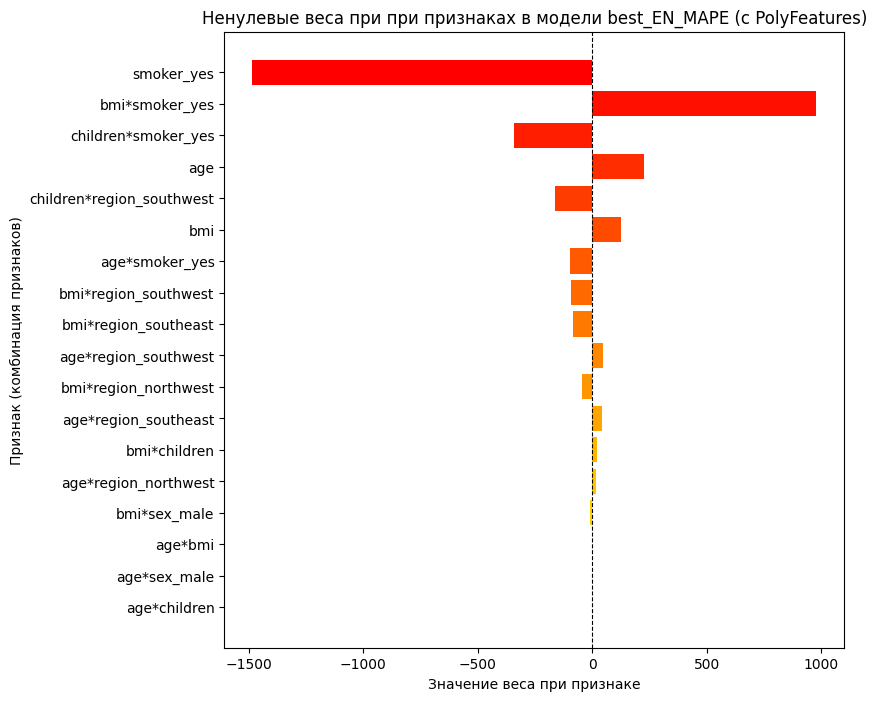

In [90]:
best_EN_MAPE.fit(X_train, y_train)

features = []
for name in best_EN_MAPE.named_steps['polyfeatures'].get_feature_names_out().tolist():
    name_to_save = name
    name_num = 0
    for actual_name in best_EN_MAPE.named_steps['scaler'].get_feature_names_out():
        name_to_save = name_to_save.replace('x' + str(name_num), actual_name)
        name_to_save = name_to_save.replace(' ', '*')
        name_num += 1
    features.append(name_to_save)

weight_data = {key: value for key, value in sorted({name: value for name, value in zip(features, best_EN_MAPE.named_steps['linreg'].coef_)}.items(), key=lambda item: -abs(item[1]))}
weight_data_not_null = {key: value for key, value in weight_data.items() if value != 0}

fig, ax = plt.subplots(1,1, figsize=(8, 8))
colors = plt.cm.autumn(np.linspace(0, 1, len(weight_data_not_null)))
ax.barh(range(len(weight_data_not_null)), weight_data_not_null.values(), color=colors)
ax.set_yticks(range(len(weight_data_not_null)))
ax.set_yticklabels(weight_data_not_null.keys())
ax.set_title('Ненулевые веса при при признаках в модели best_EN_MAPE (с PolyFeatures)')
ax.set_ylabel('Признак (комбинация признаков)')
ax.set_xlabel('Значение веса при признаке')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.show()


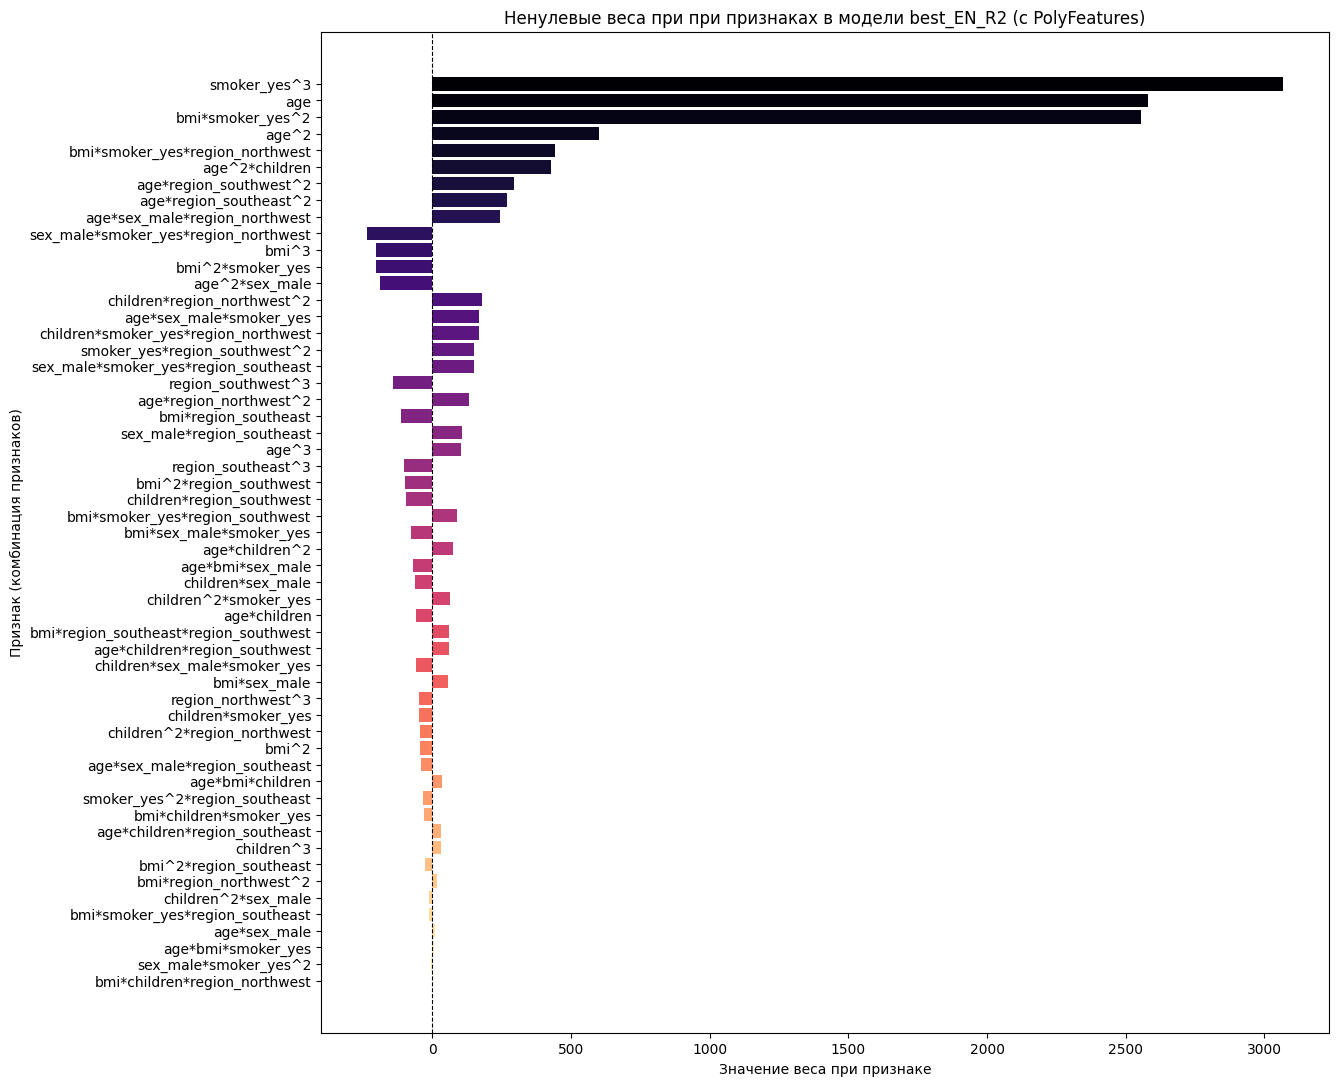

In [91]:
best_EN_R2.fit(X_train, y_train)

features = []
for name in best_EN_R2.named_steps['polyfeatures'].get_feature_names_out().tolist():
    name_to_save = name
    name_num = 0
    for actual_name in best_EN_R2.named_steps['scaler'].get_feature_names_out():
        name_to_save = name_to_save.replace('x' + str(name_num), actual_name)
        name_to_save = name_to_save.replace(' ', '*')
        name_num += 1
    features.append(name_to_save)

weight_data = {key: value for key, value in sorted({name: value for name, value in zip(features, best_EN_R2.named_steps['linreg'].coef_)}.items(), key=lambda item: -abs(item[1]))}
weight_data_not_null = {key: value for key, value in weight_data.items() if value != 0}

fig, ax = plt.subplots(1,1, figsize=(13, 13))
colors = plt.cm.magma(np.linspace(0, 1, len(weight_data_not_null)))
ax.barh(range(len(weight_data_not_null)), weight_data_not_null.values(), color=colors)
ax.set_yticks(range(len(weight_data_not_null)))
ax.set_yticklabels(weight_data_not_null.keys())
ax.set_title('Ненулевые веса при при признаках в модели best_EN_R2 (с PolyFeatures)')
ax.set_ylabel('Признак (комбинация признаков)')
ax.set_xlabel('Значение веса при признаке')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.show()

Видно, что как и ожидалось, самые большие веса у признаков (и их комбинаций) с самой высокой корреляцией с целевой переменной (то есть признаки smoker_yes, age). Но есть и интересная деталь: комбинация признаков bmi и smoker_yes также имеет высокий вес.

### 5. Заключение

Пройдусь по пунктам из дз, чтобы ответить на вопоосы:
* Я использовал метрику MAPE как основную, потому что именно она по сути важна при предсказании цены чего то или затрат на что то, то есть чем точнее мы в предсказании цены, тем лучше, в то время как метрика R2 не особо хорошо интерпретируется в контексте задачи предказания цены медицинской страховки, однако также показывает качество модели (поэтому я проводил подбор параметров именно для этих двух метрик).

* Для того чтобы получать объективный результат по метрикам, я использовал подбор параметров для лучшего результата в кроссвалидации (`GridSearchCV`), а затем смотрел результат на тестовой выборке, при этом тестовая выборка составляет 20% от исходных данных (тренировочная 80%).

* Лучше всего с поставленной задачей фактически справилась модель Lasso (с `PolynomialFeatures` порядка 2) с параметром alpha равным 100, хотя я использовал `ElasticNet` в качестве модели для которой подбирались параметры (так получилось что в итоге вышло чистое лассо).

* Результаты получились не самые лучшие, потому что при самых лучших подобранных параметрах метрика MAPE все равно больше 10% (а именно 26.41%). Вероятно (даже почти точно) зависимость целевой переменной от признаков не совсем линейная (что подтверждается scatter plot'ами построенными ранее в ноутбуке), также я подозреваю, что тут лучше справилась какая нибудь другая модель, например Random Forest (я видел ноутбуки на kaggle, в которых авторы получали метрики получше, используя именно Random Forest или градиентный бустинг)

* Модели, которые я обучал не переобучились, т.к. я использовал кросс-валидацию для подбора параметров и разделил выборку на тестовую и тренировочную. Это утверждение вроде как не перестает быть верным, даже при том, что я использовал `OneHotEncoder` до разделения выборки, т.к. по сути тут не происходит никакого data leakage.